In [13]:
library(arrow)
source("../_common/typing_utils.r")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Rcpp

Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [4]:
version <- 'EDP1-EDP2-ARB'
src_dir <- paste0('out_rds/', version)
dst_dir <- paste0('/data/srlab/AMP_collab/data/early_disease_synovium/xenium/combined/', version)

In [7]:
meta <- read_parquet(paste0(dst_dir, '/allcells_qc_harmumapclust_lineage[metadata-tiles_coarsetypes].parquet'))
meta <- as.data.frame(meta)
rownames(meta) <- meta$cell_id

In [10]:
meta$finetype = NA

files <- Sys.glob(paste0(src_dir, "/*/*[!_0-9]_allcells_finetypesvector.rds"))
message("Found ", length(files), " files")

for (i in seq_along(files)) {
    file <- files[[i]]
    message(sprintf("  [%d/%d] Reading: %s", i, length(files), basename(file)))
    
    vec <- readRDS(file)
    cells_in_common <- intersect(names(vec), rownames(meta))
    meta[cells_in_common, "finetype"] <- vec[cells_in_common]
}

message("Done. Non-NA finetypes: ", sum(!is.na(meta$finetype)), " / ", nrow(meta))

Found 9 files

  [1/9] Reading: B_allcells_finetypesvector.rds

  [2/9] Reading: Dendritic cell_allcells_finetypesvector.rds

  [3/9] Reading: Lining_allcells_finetypesvector.rds

  [4/9] Reading: Macrophage_allcells_finetypesvector.rds

  [5/9] Reading: NK_allcells_finetypesvector.rds

  [6/9] Reading: Plasma_allcells_finetypesvector.rds

  [7/9] Reading: Sublining_allcells_finetypesvector.rds

  [8/9] Reading: T_allcells_finetypesvector.rds

  [9/9] Reading: Vascular endothelial_allcells_finetypesvector.rds

Done. Non-NA finetypes: 4110396 / 5150888



In [23]:
# carry forward coarsetypes for those lineages that were not subtyped
for (ct in c("Lymphatic endothelial", "Mural", "Neuronal/glial", "Myeloid+B/plasma", "Myeloid+Stromal", "Osteoclast", "Proliferating", "Mast", "Adipocyte", "Low quality"))
{
    meta$finetype[meta$coarsetype == ct] <- ct
}

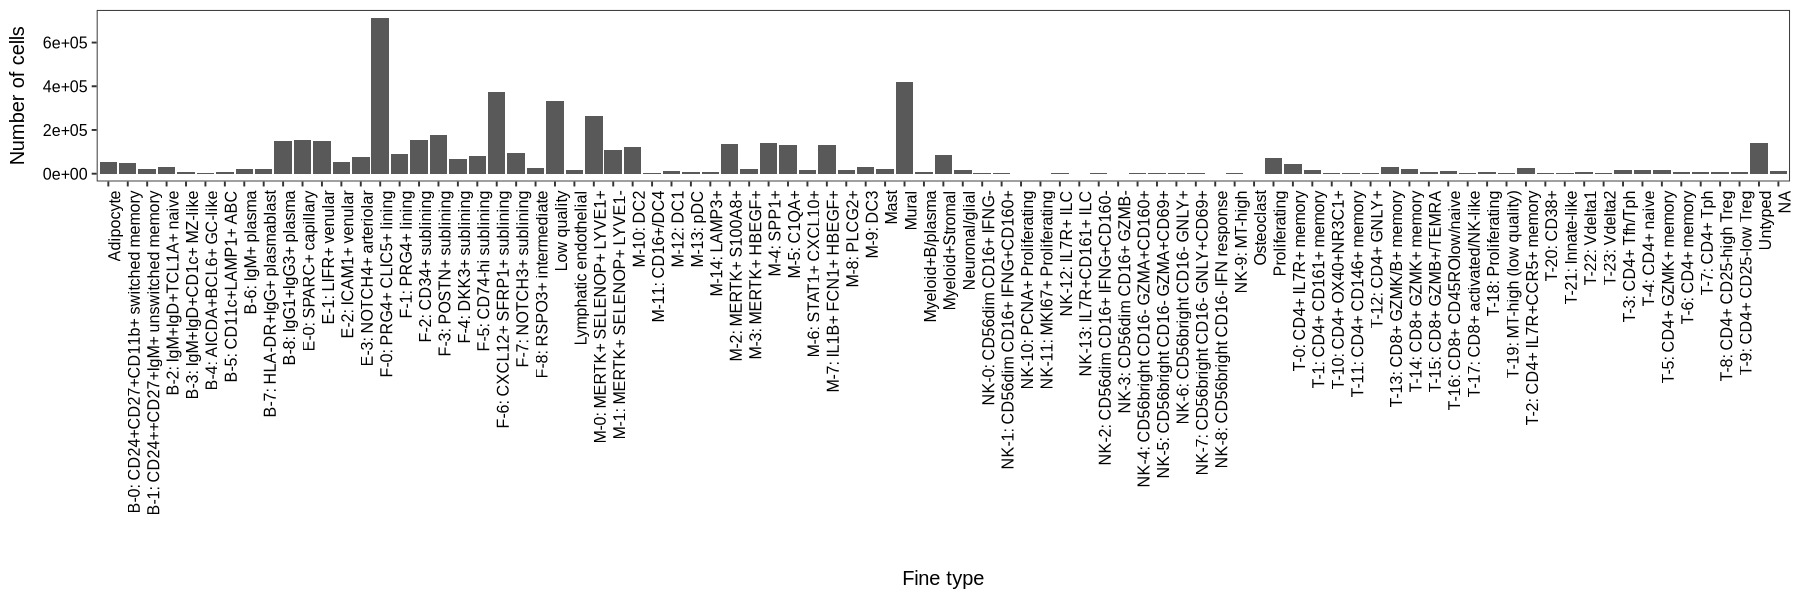

In [24]:
library(ggplot2)
fig.size(5,15)
ggplot(meta, aes(x = finetype)) +
    geom_bar() +
    theme_bw(base_size = 12) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, color = "black"),
          axis.text.y = element_text(color = "black"),
          panel.grid  = element_blank()) +
    xlab("Fine type") + ylab("Number of cells")

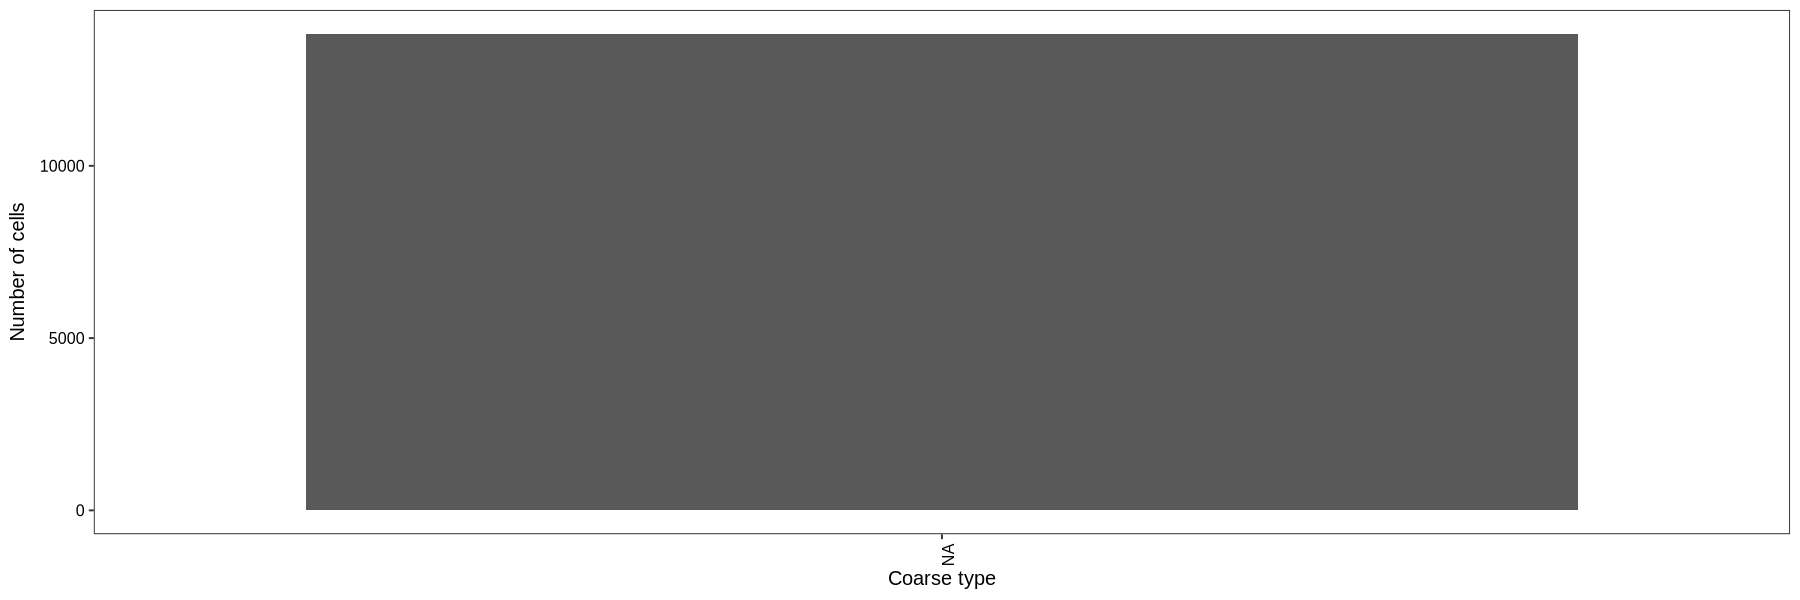

In [25]:
# see which cells didnt get fine types

fig.size(5,15)
meta |>
  dplyr::filter(is.na(finetype)) |>
  ggplot(aes(x = coarsetype)) +
    geom_bar() +
    theme_bw(base_size = 12) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, color = "black"),
          axis.text.y = element_text(color = "black"),
          panel.grid  = element_blank()) +
    xlab("Coarse type") + ylab("Number of cells")

In [26]:
# save
library(arrow)
write_parquet(meta, paste0(dst_dir, '/allcells_qc_harmumapclust_lineage[metadata-tiles_coarsetypes_finetypes].parquet'))